<a href="https://colab.research.google.com/github/gloriaconcepto/Clothing-review-embedding-project/blob/main/02_vector_analysis_and_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI-Powered Customer Review Analytics Platform
Summary

A production-ready customer review analytics platform that applies state-of-the-art embedding models, semantic search, vector databases, and dimensionality reduction to uncover customer insights. The platform supports review categorization, clustering, and intelligent retrieval, providing a strong foundation for recommendation engines, customer support automation, and product analytics

In [1]:
!pip -q install \
chromadb \
umap-learn \
scikit-learn \
plotly \
tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
# =====================================================
# Model Configuration
# =====================================================

EMBEDDING_MODEL = "text-embedding-3-small"

In [41]:
from google.colab import userdata
from openai import OpenAI

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

client = OpenAI(
    api_key=OPENAI_API_KEY
)

In [3]:
import logging
import pickle
import warnings

from pathlib import Path

import chromadb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

In [4]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/AIEngineering/WomenClothReview"
)

DATASET_DIR = PROJECT_ROOT / "datasets"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

FIGURES_DIR = OUTPUT_DIR / "figures"

VECTOR_DB_DIR = OUTPUT_DIR / "vector_db"

VECTOR_DB_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EMBEDDING_FILE = (
    OUTPUT_DIR /
    "review_embeddings.pkl"
)

DATASET_FILE = (
    DATASET_DIR /
    "cleaned_reviews.csv"
)

print(PROJECT_ROOT)

/content/drive/MyDrive/AIEngineering/WomenClothReview


In [5]:
import sys

logger = logging.getLogger(
    "VectorAnalysis"
)

logger.handlers.clear()

handler = logging.StreamHandler(
    sys.stdout
)

handler.setFormatter(

    logging.Formatter(

        "%(asctime)s | %(levelname)s | %(message)s",

        datefmt="%Y-%m-%d %H:%M:%S",

    )

)

logger.addHandler(handler)

logger.setLevel(logging.INFO)

logger.propagate = False

logger.info("Logger initialized.")

2026-07-11 10:42:48 | INFO | Logger initialized.


#### Reload Embeddings

In [14]:
logger.info(
    "Loading cleaned dataset..."
)

reviews = pd.read_csv(
    DATASET_FILE
)

logger.info(
    "Dataset loaded successfully."
)

logger.info(
    "Shape: %s",
    reviews.shape,
)

reviews.head()

2026-07-11 10:58:50 | INFO | Loading cleaned dataset...
2026-07-11 10:58:51 | INFO | Dataset loaded successfully.
2026-07-11 10:58:51 | INFO | Shape: (22600, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [7]:
logger.info(
    "Loading embeddings..."
)

with open(
    EMBEDDING_FILE,
    "rb",
) as f:

    embeddings = pickle.load(f)

logger.info(
    "Embeddings loaded successfully."
)

logger.info(
    "Total embeddings: %d",
    len(embeddings),
)

logger.info(
    "Embedding dimension: %d",
    len(embeddings[0]),
)

2026-07-11 10:43:53 | INFO | Loading embeddings...
2026-07-11 10:43:53 | INFO | Embeddings loaded successfully.
2026-07-11 10:43:53 | INFO | Total embeddings: 100
2026-07-11 10:43:53 | INFO | Embedding dimension: 1536


In [15]:
logger.info(
    "Loading cleaned dataset..."
)

reviews = pd.read_csv(
    DATASET_FILE
)

logger.info(
    "Dataset loaded successfully."
)

logger.info(
    "Shape: %s",
    reviews.shape,
)
reviews_subset = reviews.head(len(embeddings)).copy()
reviews_subset.head()

2026-07-11 10:59:18 | INFO | Loading cleaned dataset...
2026-07-11 10:59:19 | INFO | Dataset loaded successfully.
2026-07-11 10:59:19 | INFO | Shape: (22600, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## Validation & Unit Tests

In [8]:
logger.info("=" * 60)
logger.info("Running Validation Tests")
logger.info("=" * 60)

embedding_matrix = np.array(
    embeddings
)

# --------------------------------------------------
# Test 1
# --------------------------------------------------

assert len(embeddings) > 0

logger.info(
    "✓ Embeddings loaded."
)

# --------------------------------------------------
# Test 2
# --------------------------------------------------

assert len(
    embeddings
) == len(
    reviews.head(len(embeddings))
)

logger.info(
    "✓ Dataset and embeddings aligned."
)

# --------------------------------------------------
# Test 3
# --------------------------------------------------

assert embedding_matrix.ndim == 2

logger.info(
    "✓ Matrix is 2-dimensional."
)

# --------------------------------------------------
# Test 4
# --------------------------------------------------

assert embedding_matrix.shape[1] == 1536

logger.info(
    "✓ Embedding dimension verified."
)

# --------------------------------------------------
# Test 5
# --------------------------------------------------

assert np.isfinite(
    embedding_matrix
).all()

logger.info(
    "✓ No NaN or Infinite values."
)

# --------------------------------------------------
# Test 6
# --------------------------------------------------

assert embedding_matrix.dtype in (
    np.float64,
    np.float32,
)

logger.info(
    "✓ Numeric dtype verified."
)

# --------------------------------------------------
# Test 7
# --------------------------------------------------

assert np.linalg.norm(
    embedding_matrix,
    axis=1,
).min() > 0

logger.info(
    "✓ No zero vectors detected."
)

# --------------------------------------------------
# Test 8
# --------------------------------------------------

assert len(

    np.unique(
        embedding_matrix,
        axis=0,
    )

) > 1

logger.info(
    "✓ Embeddings are unique."
)

logger.info("=" * 60)
logger.info("ALL TESTS PASSED")
logger.info("=" * 60)

2026-07-11 10:44:39 | INFO | ============================================================
2026-07-11 10:44:39 | INFO | Running Validation Tests
2026-07-11 10:44:39 | INFO | ============================================================
2026-07-11 10:44:39 | INFO | ✓ Embeddings loaded.
2026-07-11 10:44:39 | INFO | ✓ Dataset and embeddings aligned.
2026-07-11 10:44:39 | INFO | ✓ Matrix is 2-dimensional.
2026-07-11 10:44:39 | INFO | ✓ Embedding dimension verified.
2026-07-11 10:44:39 | INFO | ✓ No NaN or Infinite values.
2026-07-11 10:44:39 | INFO | ✓ Numeric dtype verified.
2026-07-11 10:44:39 | INFO | ✓ No zero vectors detected.
2026-07-11 10:44:39 | INFO | ✓ Embeddings are unique.
2026-07-11 10:44:39 | INFO | ============================================================
2026-07-11 10:44:39 | INFO | ALL TESTS PASSED
2026-07-11 10:44:39 | INFO | ============================================================


## Prepare Embedding Matrix

In [9]:
# =====================================================
# Prepare Embedding Matrix
# =====================================================

logger.info("=" * 60)
logger.info("Preparing Embedding Matrix")
logger.info("=" * 60)

embedding_matrix = np.array(
    embeddings,
    dtype=np.float32,
)

logger.info(
    "Embedding matrix shape: %s",
    embedding_matrix.shape,
)

logger.info(
    "Embedding dtype: %s",
    embedding_matrix.dtype,
)

logger.info("=" * 60)

2026-07-11 10:47:37 | INFO | ============================================================
2026-07-11 10:47:37 | INFO | Preparing Embedding Matrix
2026-07-11 10:47:37 | INFO | ============================================================
2026-07-11 10:47:37 | INFO | Embedding matrix shape: (100, 1536)
2026-07-11 10:47:37 | INFO | Embedding dtype: float32
2026-07-11 10:47:37 | INFO | ============================================================


## Dataset Summary

In [16]:
# =====================================================
# Dataset Summary
# =====================================================

logger.info("=" * 60)
logger.info("Dataset Summary")
logger.info("=" * 60)

print(f"Reviews          : {len(reviews_subset)}")
print(f"Embeddings       : {len(embeddings)}")
print(f"Dimensions       : {embedding_matrix.shape[1]}")

print("\nColumns\n")

display(reviews_subset.columns.to_frame())

print("\nFirst Review\n")

print(reviews.iloc[0]["Review Text"])

2026-07-11 11:00:01 | INFO | ============================================================
2026-07-11 11:00:01 | INFO | Dataset Summary
2026-07-11 11:00:01 | INFO | ============================================================
Reviews          : 100
Embeddings       : 100
Dimensions       : 1536

Columns



,0
Unnamed: 0,Unnamed: 0
Clothing ID,Clothing ID
Age,Age
Title,Title
Review Text,Review Text
Rating,Rating
Recommended IND,Recommended IND
Positive Feedback Count,Positive Feedback Count
Division Name,Division Name
Department Name,Department Name



First Review

Absolutely wonderful - silky and sexy and comfortable


## Run t-SNE

In [17]:
# =====================================================
# t-SNE
# =====================================================

logger.info("=" * 60)
logger.info("Running t-SNE")
logger.info("=" * 60)

n_samples = len(
    embedding_matrix
)

perplexity = min(
    30,
    max(
        5,
        n_samples // 3,
    ),
)

logger.info(
    "Using perplexity=%d",
    perplexity,
)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
)

embeddings_2d = tsne.fit_transform(
    embedding_matrix
)

logger.info(
    "t-SNE completed."
)

logger.info(
    "Output shape: %s",
    embeddings_2d.shape,
)

2026-07-11 11:00:12 | INFO | ============================================================
2026-07-11 11:00:12 | INFO | Running t-SNE
2026-07-11 11:00:12 | INFO | ============================================================
2026-07-11 11:00:12 | INFO | Using perplexity=30
2026-07-11 11:00:13 | INFO | t-SNE completed.
2026-07-11 11:00:13 | INFO | Output shape: (100, 2)


## KMeans Clustering

In [18]:
# =====================================================
# KMeans
# =====================================================

logger.info("=" * 60)
logger.info("Running KMeans")
logger.info("=" * 60)

N_CLUSTERS = 5

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=20,
)

clusters = kmeans.fit_predict(
    embedding_matrix
)

logger.info(
    "KMeans completed."
)

reviews_subset["Cluster"] = clusters

2026-07-11 11:02:06 | INFO | ============================================================
2026-07-11 11:02:06 | INFO | Running KMeans
2026-07-11 11:02:06 | INFO | ============================================================
2026-07-11 11:02:06 | INFO | KMeans completed.


## Evaluate Clustering

In [19]:
# =====================================================
# Silhouette Score
# =====================================================

logger.info("=" * 60)
logger.info("Evaluating Clusters")
logger.info("=" * 60)

score = silhouette_score(
    embedding_matrix,
    clusters,
)

logger.info(
    "Silhouette Score: %.4f",
    score,
)

print(
    f"Silhouette Score: {score:.4f}"
)

2026-07-11 11:03:12 | INFO | ============================================================
2026-07-11 11:03:12 | INFO | Evaluating Clusters
2026-07-11 11:03:12 | INFO | ============================================================
2026-07-11 11:03:12 | INFO | Silhouette Score: 0.0257
Silhouette Score: 0.0257


## t-SNE Visualization

2026-07-11 11:03:52 | INFO | ============================================================
2026-07-11 11:03:52 | INFO | Creating Visualization
2026-07-11 11:03:52 | INFO | ============================================================
2026-07-11 11:03:55 | INFO | Figure saved.


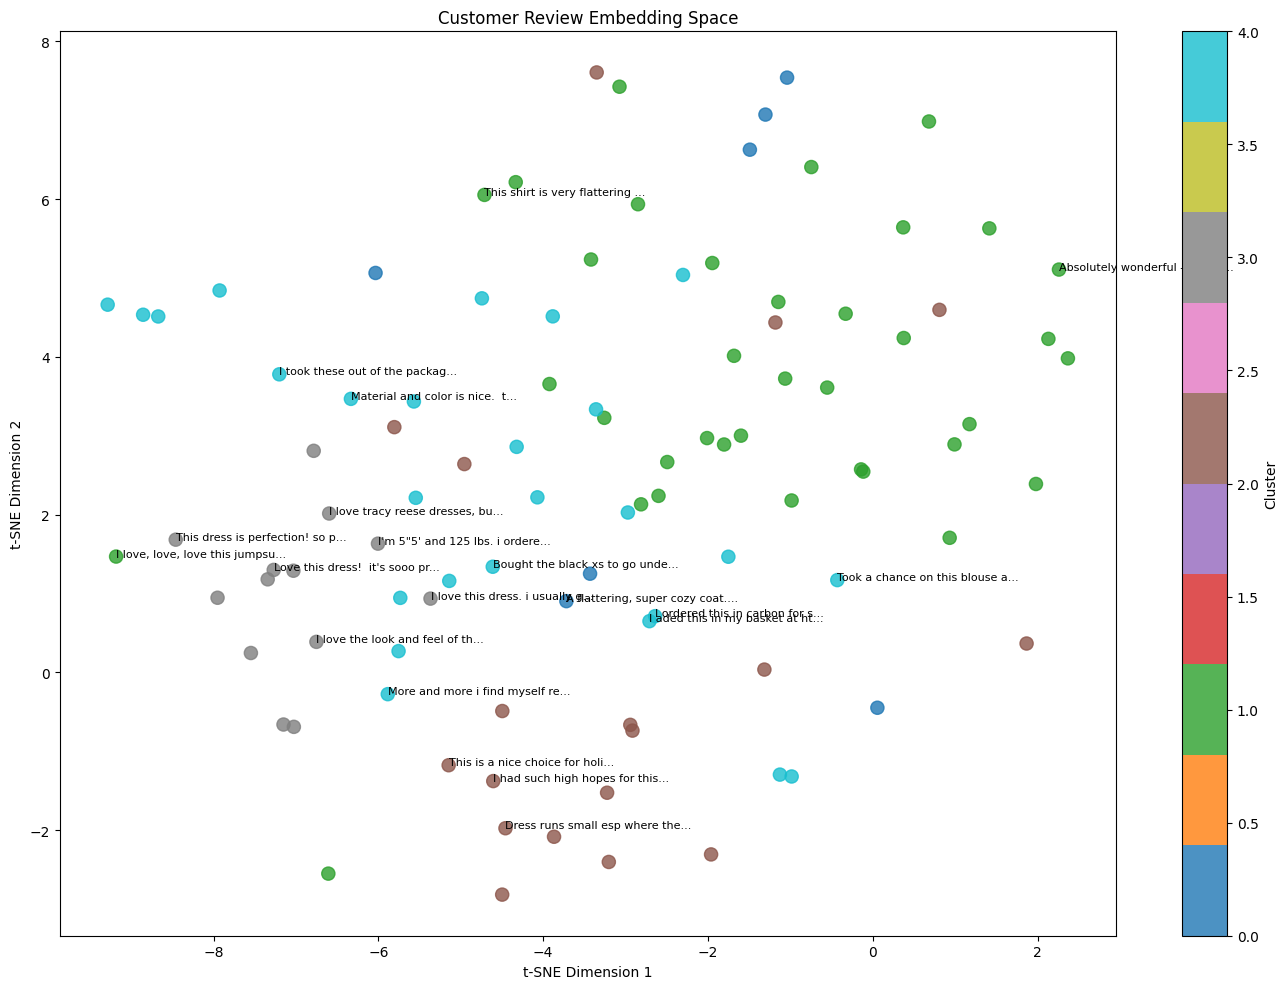

In [20]:
# =====================================================
# Visualization
# =====================================================

logger.info("=" * 60)
logger.info("Creating Visualization")
logger.info("=" * 60)

plt.figure(
    figsize=(14,10)
)

scatter = plt.scatter(

    embeddings_2d[:,0],

    embeddings_2d[:,1],

    c=clusters,

    cmap="tab10",

    s=90,

    alpha=.8,

)

review_texts = (
    reviews["Review Text"]
    .fillna("")
    .tolist()
)

for i in range(
    min(
        20,
        len(review_texts),
    )
):

    plt.annotate(

        review_texts[i][:30] + "...",

        (
            embeddings_2d[i,0],
            embeddings_2d[i,1],
        ),

        fontsize=8,

    )

plt.title(
    "Customer Review Embedding Space"
)

plt.xlabel(
    "t-SNE Dimension 1"
)

plt.ylabel(
    "t-SNE Dimension 2"
)

plt.colorbar(
    scatter,
    label="Cluster",
)

plt.tight_layout()

figure_path = (

    FIGURES_DIR /

    "tsne_clusters.png"

)

plt.savefig(

    figure_path,

    dpi=300,

    bbox_inches="tight",

)

logger.info(
    "Figure saved."
)

plt.show()

## Cluster Statistics

In [22]:
# =====================================================
# Cluster Distribution
# =====================================================

logger.info("=" * 60)
logger.info("Cluster Distribution")
logger.info("=" * 60)

cluster_summary = (

    reviews_subset

    .groupby("Cluster")

    .size()

    .reset_index(

        name="Reviews"

    )

)

display(
    cluster_summary
)

2026-07-11 11:06:29 | INFO | ============================================================
2026-07-11 11:06:29 | INFO | Cluster Distribution
2026-07-11 11:06:29 | INFO | ============================================================


,Cluster,Reviews
0,0,7
1,1,36
2,2,18
3,3,13
4,4,26


## Representative Reviews

In [27]:
type(reviews_subset)

str

In [28]:
reviews_subset = reviews.head(len(embeddings)).copy()
reviews_subset["Cluster"] = clusters

In [29]:
# =====================================================
# Representative Reviews
# =====================================================

logger.info("=" * 60)
logger.info("Representative Reviews")
logger.info("=" * 60)

for cluster in sorted(
    reviews_subset["Cluster"].unique()
):

    print("\n" + "=" * 70)
    print(f"CLUSTER {cluster}")
    print("=" * 70)

    sample = (
        reviews_subset[
            reviews_subset["Cluster"] == cluster
        ]
        .head(5)
    )

    for review in sample["Review Text"]:

        print("•", review)

2026-07-11 11:10:34 | INFO | ============================================================
2026-07-11 11:10:34 | INFO | Representative Reviews
2026-07-11 11:10:34 | INFO | ============================================================

CLUSTER 0
• A flattering, super cozy coat.  will work well for cold, dry days and will look good with jeans or a dressier outfit.  i am 5' 5'', about 135 and the small fits great.
• I have been waiting for this sweater coat to ship for weeks and i was so excited for it to arrive. this coat is not true to size and made me look short and squat. the sleeves are very wide (although long). as a light weight fall coat the sleeves don't need to be as wide because you wouldn't be layerng too much underneath. the buttons need to be moved at least three inches in for a nicer fit. i thought about redoing the buttons myself but the sleeves looked even more out of proportion with a tigh
• This sweater is so comfy and classic - it balances a quirky hand-knit look with a 

## Cluster Interpretation

In [31]:
# =====================================================
# Cluster Summary
# =====================================================

cluster_report = (

    reviews_subset

    .groupby("Cluster")

    .agg(

        Reviews=(

            "Review Text",

            "count",

        ),

        Average_Rating=(

            "Rating",

            "mean",

        ),

        Average_Positive_Feedback=(

            "Positive Feedback Count",

            "mean",

        ),

    )

    .round(2)

)

display(
    cluster_report
)

,Reviews,Average_Rating,Average_Positive_Feedback
Cluster,,,
0,7,4.57,0.14
1,36,4.47,3.47
2,18,2.44,2.00
3,13,4.38,1.00
4,26,4.35,3.04


## Initialize ChromaDB

In [32]:
!pip install -q chromadb

In [33]:
# =====================================================
# Initialize ChromaDB
# =====================================================

logger.info("=" * 60)
logger.info("Initializing ChromaDB")
logger.info("=" * 60)

import chromadb

VECTOR_DB_PATH = OUTPUT_DIR / "vector_db"

client = chromadb.PersistentClient(
    path=str(VECTOR_DB_PATH)
)

logger.info(
    "Vector database location: %s",
    VECTOR_DB_PATH,
)

2026-07-11 11:22:27 | INFO | ============================================================
2026-07-11 11:22:27 | INFO | Initializing ChromaDB
2026-07-11 11:22:27 | INFO | ============================================================
2026-07-11 11:22:28 | INFO | Vector database location: /content/drive/MyDrive/AIEngineering/WomenClothReview/outputs/vector_db


## Create Collection

In [34]:
# =====================================================
# Create Collection
# =====================================================

COLLECTION_NAME = "customer_reviews"

try:

    client.delete_collection(
        COLLECTION_NAME
    )

    logger.info(
        "Existing collection removed."
    )

except:

    logger.info(
        "Collection does not exist."
    )

collection = client.create_collection(
    name=COLLECTION_NAME
)

logger.info(
    "Collection created successfully."
)

2026-07-11 11:22:57 | INFO | Collection does not exist.
2026-07-11 11:22:57 | INFO | Collection created successfully.


## Index Review Embeddings

In [35]:
# =====================================================
# Store Review Embeddings
# =====================================================

logger.info("=" * 60)
logger.info("Indexing Reviews")
logger.info("=" * 60)

documents = (
    reviews_subset["Review Text"]
    .fillna("")
    .tolist()
)

metadatas = []

for _, row in reviews_subset.iterrows():

    metadatas.append({

        "rating": int(
            row["Rating"]
        ),

        "recommended": bool(
            row["Recommended IND"]
        ),

        "division": str(
            row["Division Name"]
        ),

        "department": str(
            row["Department Name"]
        ),

        "class": str(
            row["Class Name"]
        ),

        "cluster": int(
            row["Cluster"]
        ),

    })

ids = [

    f"review_{i}"

    for i in range(
        len(documents)
    )

]

collection.add(

    ids=ids,

    documents=documents,

    embeddings=embeddings,

    metadatas=metadatas,

)

logger.info(
    "%d reviews indexed.",
    len(documents),
)

2026-07-11 11:23:37 | INFO | ============================================================
2026-07-11 11:23:37 | INFO | Indexing Reviews
2026-07-11 11:23:37 | INFO | ============================================================
2026-07-11 11:23:37 | INFO | 100 reviews indexed.


## Verify ChromaDB

In [36]:
# =====================================================
# Verify Collection
# =====================================================

logger.info("=" * 60)
logger.info("Verifying Collection")
logger.info("=" * 60)

count = collection.count()

print(
    f"Documents Indexed: {count}"
)

assert count == len(
    reviews_subset
)

logger.info(
    "Verification passed."
)

2026-07-11 11:24:02 | INFO | ============================================================
2026-07-11 11:24:02 | INFO | Verifying Collection
2026-07-11 11:24:02 | INFO | ============================================================
Documents Indexed: 100
2026-07-11 11:24:02 | INFO | Verification passed.


Semantic Search Function

In [42]:
# =====================================================
# Semantic Search
# =====================================================

def semantic_search(
    query,
    n_results=5,
):

    response = client.embeddings.create(

        model=EMBEDDING_MODEL,

        input=query,

    )

    query_embedding = (
        response.data[0].embedding
    )

    results = collection.query(

        query_embeddings=[
            query_embedding
        ],

        n_results=n_results,

    )

    return results

## Run Semantic Search

In [43]:
# =====================================================
# Example Search
# =====================================================

query = (
    "comfortable soft dress"
)

results = semantic_search(
    query,
    n_results=5,
)

## Display Search Results

In [44]:
# =====================================================
# Display Results
# =====================================================

logger.info("=" * 60)
logger.info("Semantic Search Results")
logger.info("=" * 60)

for rank, (
    document,
    metadata,
    distance,
) in enumerate(

    zip(

        results["documents"][0],

        results["metadatas"][0],

        results["distances"][0],

    ),

    start=1,

):

    print("=" * 70)

    print(
        f"Rank {rank}"
    )

    print("=" * 70)

    print(
        f"Distance : {distance:.4f}"
    )

    print(
        f"Rating   : {metadata['rating']}"
    )

    print(
        f"Division : {metadata['division']}"
    )

    print(
        f"Cluster  : {metadata['cluster']}"
    )

    print()

    print(document)

    print()

2026-07-11 11:35:59 | INFO | ============================================================
2026-07-11 11:35:59 | INFO | Semantic Search Results
2026-07-11 11:35:59 | INFO | ============================================================
Rank 1
Distance : 0.9317
Rating   : 4
Division : Initmates
Cluster  : 1

Absolutely wonderful - silky and sexy and comfortable

Rank 2
Distance : 0.9617
Rating   : 5
Division : General
Cluster  : 1

Very comfortable, material is good, cut out on sleeves flattering

Rank 3
Distance : 1.0861
Rating   : 5
Division : General Petite
Cluster  : 1

Loved this top. great design. comfortable and unique. soft material

Rank 4
Distance : 1.0864
Rating   : 3
Division : General Petite
Cluster  : 1

I am in need of easy comfortable tops for everyday wear. i bought this top mostly because of the cute buttons. when i received it, it looked exactly as it does in the picture online, however, the buttons kept slipping out of their homes because the holes were slightly too big

## Search Evaluation

In [45]:
# =====================================================
# Search Evaluation
# =====================================================

logger.info("=" * 60)
logger.info("Search Evaluation")
logger.info("=" * 60)

distances = results["distances"][0]

print(

    pd.DataFrame({

        "Rank": range(

            1,

            len(distances)+1,

        ),

        "Distance": distances,

    })

)

2026-07-11 11:38:09 | INFO | ============================================================
2026-07-11 11:38:09 | INFO | Search Evaluation
2026-07-11 11:38:09 | INFO | ============================================================
   Rank  Distance
0     1  0.931724
1     2  0.961652
2     3  1.086094
3     4  1.086421
4     5  1.092403


## Unit Tests

In [46]:
# =====================================================
# Unit Tests
# =====================================================

logger.info("=" * 60)
logger.info("Running Pipeline Validation")
logger.info("=" * 60)

# -----------------------------------------------------
# Embeddings
# -----------------------------------------------------

assert embedding_matrix.shape[0] == len(reviews_subset)

assert embedding_matrix.shape[1] == 1536

logger.info("✓ Embedding matrix validated.")

# -----------------------------------------------------
# t-SNE
# -----------------------------------------------------

assert embeddings_2d.shape == (
    len(reviews_subset),
    2,
)

logger.info("✓ t-SNE output validated.")

# -----------------------------------------------------
# KMeans
# -----------------------------------------------------

assert len(clusters) == len(reviews_subset)

assert len(np.unique(clusters)) == N_CLUSTERS

logger.info("✓ KMeans clustering validated.")

# -----------------------------------------------------
# ChromaDB
# -----------------------------------------------------

assert collection.count() == len(
    reviews_subset
)

logger.info("✓ ChromaDB document count validated.")

# -----------------------------------------------------
# Semantic Search
# -----------------------------------------------------

query = "comfortable soft dress"

results = semantic_search(
    query,
    n_results=5,
)

assert len(
    results["documents"][0]
) == 5

assert len(
    results["distances"][0]
) == 5

logger.info("✓ Semantic search validated.")

# -----------------------------------------------------
# Metadata
# -----------------------------------------------------

metadata = results["metadatas"][0][0]

required_keys = [

    "rating",

    "recommended",

    "division",

    "department",

    "class",

    "cluster",

]

for key in required_keys:

    assert key in metadata

logger.info(
    "✓ Metadata validated."
)

logger.info("=" * 60)
logger.info("ALL UNIT TESTS PASSED")
logger.info("=" * 60)

2026-07-11 11:44:30 | INFO | ============================================================
2026-07-11 11:44:30 | INFO | Running Pipeline Validation
2026-07-11 11:44:30 | INFO | ============================================================
2026-07-11 11:44:30 | INFO | ✓ Embedding matrix validated.
2026-07-11 11:44:30 | INFO | ✓ t-SNE output validated.
2026-07-11 11:44:30 | INFO | ✓ KMeans clustering validated.
2026-07-11 11:44:30 | INFO | ✓ ChromaDB document count validated.
2026-07-11 11:44:30 | INFO | ✓ Semantic search validated.
2026-07-11 11:44:30 | INFO | ✓ Metadata validated.
2026-07-11 11:44:30 | INFO | ============================================================
2026-07-11 11:44:30 | INFO | ALL UNIT TESTS PASSED
2026-07-11 11:44:30 | INFO | ============================================================


## Persist Analysis Artifacts

In [47]:
# =====================================================
# Persist Analysis Results
# =====================================================

import json

logger.info("=" * 60)
logger.info("Saving Analysis Artifacts")
logger.info("=" * 60)

# ---------------------------------------
# Clustered Dataset
# ---------------------------------------

clustered_dataset = (
    OUTPUT_DIR /
    "clustered_reviews.csv"
)

reviews_subset.to_csv(
    clustered_dataset,
    index=False,
)

logger.info(
    "Clustered dataset saved."
)

# ---------------------------------------
# Cluster Centers
# ---------------------------------------

cluster_centers = (
    OUTPUT_DIR /
    "cluster_centers.npy"
)

np.save(
    cluster_centers,
    kmeans.cluster_centers_,
)

logger.info(
    "Cluster centers saved."
)

# ---------------------------------------
# t-SNE Coordinates
# ---------------------------------------

tsne_coordinates = (
    OUTPUT_DIR /
    "tsne_coordinates.npy"
)

np.save(
    tsne_coordinates,
    embeddings_2d,
)

logger.info(
    "t-SNE coordinates saved."
)

# ---------------------------------------
# Analysis Summary
# ---------------------------------------

summary = {

    "reviews": len(reviews_subset),

    "embedding_dimension": 1536,

    "clusters": N_CLUSTERS,

    "silhouette_score": float(score),

    "vector_database": COLLECTION_NAME,

}

summary_file = (
    OUTPUT_DIR /
    "analysis_summary.json"
)

with open(
    summary_file,
    "w",
) as f:

    json.dump(
        summary,
        f,
        indent=4,
    )

logger.info(
    "Summary saved."
)

logger.info("=" * 60)
logger.info("All artifacts saved.")
logger.info("=" * 60)

2026-07-11 11:45:01 | INFO | ============================================================
2026-07-11 11:45:01 | INFO | Saving Analysis Artifacts
2026-07-11 11:45:01 | INFO | ============================================================
2026-07-11 11:45:01 | INFO | Clustered dataset saved.
2026-07-11 11:45:01 | INFO | Cluster centers saved.
2026-07-11 11:45:01 | INFO | t-SNE coordinates saved.
2026-07-11 11:45:01 | INFO | Summary saved.
2026-07-11 11:45:01 | INFO | ============================================================
2026-07-11 11:45:01 | INFO | All artifacts saved.
2026-07-11 11:45:01 | INFO | ============================================================



## Final Analysis Report

In [48]:
# =====================================================
# Final Analysis Report
# =====================================================

logger.info("=" * 60)
logger.info("FINAL REPORT")
logger.info("=" * 60)

print("\n")
print("=" * 70)
print("VECTOR ANALYSIS REPORT")
print("=" * 70)

print(
    f"Reviews Analysed        : {len(reviews_subset)}"
)

print(
    f"Embedding Dimension     : {embedding_matrix.shape[1]}"
)

print(
    f"Clusters                : {N_CLUSTERS}"
)

print(
    f"Silhouette Score        : {score:.4f}"
)

print(
    f"Vector Database Entries : {collection.count()}"
)

print(
    f"t-SNE Figure            : {FIGURES_DIR / 'tsne_clusters.png'}"
)

print(
    f"Clustered Dataset       : {clustered_dataset}"
)

print(
    f"Analysis Summary        : {summary_file}"
)

print("=" * 70)

logger.info("Notebook completed successfully.")

2026-07-11 11:45:43 | INFO | ============================================================
2026-07-11 11:45:43 | INFO | FINAL REPORT
2026-07-11 11:45:43 | INFO | ============================================================


VECTOR ANALYSIS REPORT
Reviews Analysed        : 100
Embedding Dimension     : 1536
Clusters                : 5
Silhouette Score        : 0.0257
Vector Database Entries : 100
t-SNE Figure            : /content/drive/MyDrive/AIEngineering/WomenClothReview/outputs/figures/tsne_clusters.png
Clustered Dataset       : /content/drive/MyDrive/AIEngineering/WomenClothReview/outputs/clustered_reviews.csv
Analysis Summary        : /content/drive/MyDrive/AIEngineering/WomenClothReview/outputs/analysis_summary.json
2026-07-11 11:45:43 | INFO | Notebook completed successfully.
